# SpaNCy — Interactive Exploration Notebook

Step-by-step walkthrough of the SpaNCy pipeline:
1. Load & inspect data
2. Preprocessing (log1p, scaling, cycle assignment)
3. Spatial k-NN graph construction
4. Model architecture exploration
5. Mini-batch sampling
6. Single training step (forward + backward)
7. Full training loop
8. Inference & output inspection

## 0. Colab Setup

Run this section first if using Google Colab. It installs dependencies, uploads `spancy.py`, and adds it to the Python path.

In [1]:
# ── Install dependencies (Colab) ──
# torch is pre-installed on Colab; we just need torch-geometric + friends

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# 1. Core scientific stack (usually pre-installed, but pin to be safe)
install("anndata")
install("scikit-learn")

# 2. torch-geometric — must match the Colab torch+CUDA versions
#    This auto-detects torch version and installs compatible wheels.
import torch
TORCH_VERSION = torch.__version__.split("+")[0]   # e.g. "2.5.0"
CUDA_TAG = torch.version.cuda                      # e.g. "12.4" or None

if CUDA_TAG:
    cuda_short = "cu" + CUDA_TAG.replace(".", "")   # e.g. "cu124"
else:
    cuda_short = "cpu"

PYGS_URL = f"https://data.pyg.org/whl/torch-{TORCH_VERSION}+{cuda_short}.html"
print(f"PyG wheel index: {PYGS_URL}")

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "torch-scatter", "torch-sparse",
    "-f", PYGS_URL,
])
install("torch-geometric")

print(f"\ntorch {torch.__version__}  CUDA {CUDA_TAG}")
import torch_geometric
print(f"torch-geometric {torch_geometric.__version__}")
print("All dependencies installed.")

PyG wheel index: https://data.pyg.org/whl/torch-2.10.0+cu128.html

torch 2.10.0+cu128  CUDA 12.8
torch-geometric 2.7.0
All dependencies installed.


In [2]:
# ── Upload spancy.py to Colab ──
# Option A: Upload from your machine via browser dialog
from google.colab import files
uploaded = files.upload()  # click "Choose Files" and select spancy.py

# Option B (alternative): If spancy.py is on Google Drive, uncomment below:
# from google.colab import drive
# drive.mount("/content/drive")
# !cp "/content/drive/MyDrive/path/to/spancy.py" .

# Verify it landed in /content (Colab working dir)
import os
assert os.path.exists("spancy.py"), "spancy.py not found — upload it first"
print(f"spancy.py uploaded ({os.path.getsize('spancy.py'):,} bytes)")

# No sys.path hack needed — Colab's working dir is /content,
# which is already on the Python path.

Saving spancy.py to spancy.py
spancy.py uploaded (38,624 bytes)


In [3]:
# Downloads the PRAD_anndata file

!wget https://zenodo.org/records/16383766/files/PRAD_anndata.h5ad

--2026-03-16 07:38:45--  https://zenodo.org/records/16383766/files/PRAD_anndata.h5ad
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.52.235, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 392811382 (375M) [application/octet-stream]
Saving to: ‘PRAD_anndata.h5ad’

PRAD_anndata.h5ad   100%[===================>] 374.61M  11.8MB/s    in 33s     

2026-03-16 07:39:19 (11.3 MB/s) - ‘PRAD_anndata.h5ad’ saved [392811382/392811382]



In [ ]:
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.spatial import cKDTree
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch.optim import AdamW

# Local imports
from spancy import (
    DEFAULT_CYCLE_CONFIG,
    load_adata, get_spatial_coords, get_scene_ids,
    assign_marker_cycles, log1p_scale, build_knn_graph,
    CycleDegradationModel, SpatialGNNEncoder, ResidualDecoder,
    ProjectionHead, BatchDiscriminator, SpaNCy,
    SpatialClusterSampler, build_subgraph, nt_xent_loss,
    location_scale_loss, grad_reverse, train
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Load & Inspect Data

Update `DATA_PATH` to point to your PRAD-CyCIF `.h5ad` file.

In [6]:
DATA_PATH = "/content/PRAD_anndata.h5ad"  # <-- change this

adata = load_adata(DATA_PATH)
print(adata)
print(f"\nMarkers: {list(adata.var_names)}")
print(f"Batches: {adata.obs['batch'].unique().tolist()}")
print(f"Shape:   {adata.shape}")
print(f"\nobs columns: {list(adata.obs.columns)}")
print(f"obsm keys:   {list(adata.obsm.keys())}")
print(f"layers:      {list(adata.layers.keys())}")

07:40:31 [INFO] Loading /content/PRAD_anndata.h5ad
07:40:33 [INFO] Loaded 1760530 cells x 20 markers
07:40:33 [INFO] Using 'batch_id' as batch column
07:40:33 [INFO] Setting var_names from var['marker_name']
AnnData object with n_obs × n_vars = 1760530 × 20
    obs: 'cell_id', 'sample_id', 'scene_id', 'batch_id', 'x', 'y', 'batch'
    var: 'marker_name'
    uns: 'image_dimensions'

Markers: ['DAPI_R1', 'EPCAM', 'CD56', 'CD45', 'aSMA', 'ChromA', 'CK14', 'Ki67', 'GZMB', 'ECAD', 'PD1', 'CD31', 'CD45RA', 'HLADRB1', 'CD3', 'p53', 'FOXA1', 'CDX2', 'CD20', 'NOTCH1']
Batches: ['batch4', 'batch1', 'batch2', 'batch3', 'batch5', 'batch7', 'batch6']
Shape:   (1760530, 20)

obs columns: ['cell_id', 'sample_id', 'scene_id', 'batch_id', 'x', 'y', 'batch']
obsm keys:   []
layers:      []


Raw expression stats:
  Min:    0.0000
  Max:    65535.0000
  Mean:   4845.0224
  Median: 2337.5542
  % zero: 0.2%


/tmp/ipykernel_21942/1797251351.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X_raw[:, i] for i in range(X_raw.shape[1])], labels=adata.var_names, vert=True)


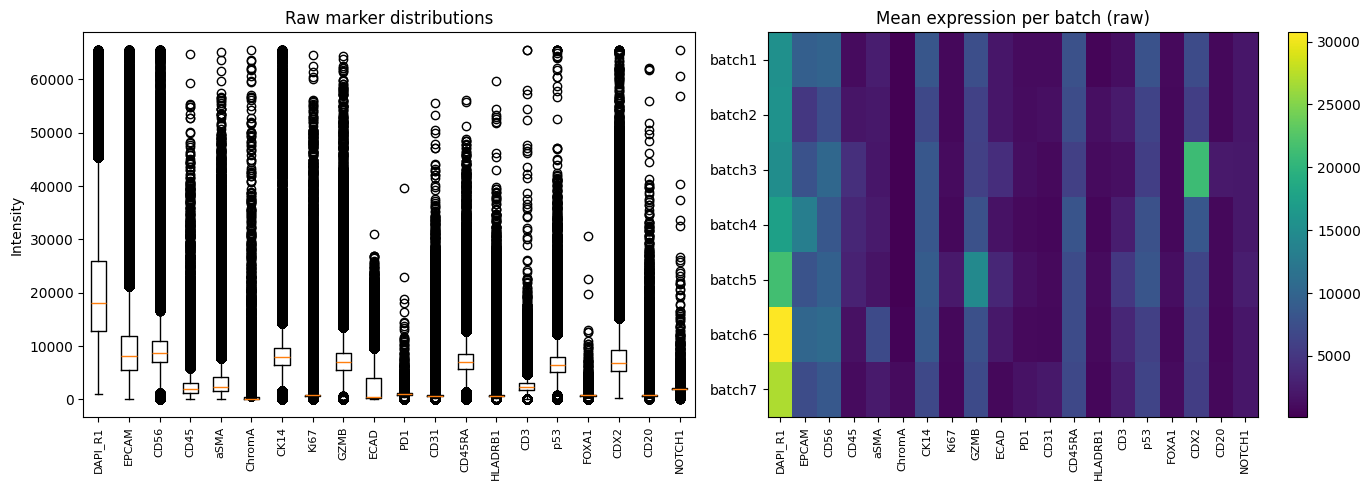

In [7]:
# Raw expression statistics
X_raw = np.asarray(adata.X) if not sp.issparse(adata.X) else adata.X.toarray()

print("Raw expression stats:")
print(f"  Min:    {X_raw.min():.4f}")
print(f"  Max:    {X_raw.max():.4f}")
print(f"  Mean:   {X_raw.mean():.4f}")
print(f"  Median: {np.median(X_raw):.4f}")
print(f"  % zero: {(X_raw == 0).mean() * 100:.1f}%")

# Per-marker stats
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([X_raw[:, i] for i in range(X_raw.shape[1])], labels=adata.var_names, vert=True)
axes[0].set_xticklabels(adata.var_names, rotation=90, fontsize=8)
axes[0].set_title("Raw marker distributions")
axes[0].set_ylabel("Intensity")

# Per-batch mean expression
batch_codes = adata.obs["batch"].astype("category").cat.codes.values
batch_names = adata.obs["batch"].astype("category").cat.categories.tolist()
batch_means = np.array([X_raw[batch_codes == b].mean(axis=0) for b in range(len(batch_names))])
im = axes[1].imshow(batch_means, aspect="auto", cmap="viridis")
axes[1].set_yticks(range(len(batch_names)))
axes[1].set_yticklabels(batch_names)
axes[1].set_xticks(range(len(adata.var_names)))
axes[1].set_xticklabels(adata.var_names, rotation=90, fontsize=8)
axes[1].set_title("Mean expression per batch (raw)")
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## 2. Preprocessing — log1p + RobustScaler + Cycle Assignment

After log1p + StandardScaler:
  Shape: (1760530, 20)
  Mean per marker (should be ~0): [ 0.0181 -0.0091 -0.0635  0.0658  0.1285  0.3269 -0.1022  0.3079 -0.0306
  0.2697  0.0348  0.3568 -0.0953  0.3266  0.0072 -0.0908  0.0725  0.1552
  0.5819  0.0756]
  Std per marker (should be ~1):  [0.724  0.822  1.3637 0.7483 0.8154 0.6129 1.3371 2.344  1.1666 0.5308
 1.2143 1.9898 1.5088 1.5679 1.2706 1.377  1.9521 0.937  1.7646 1.0419]


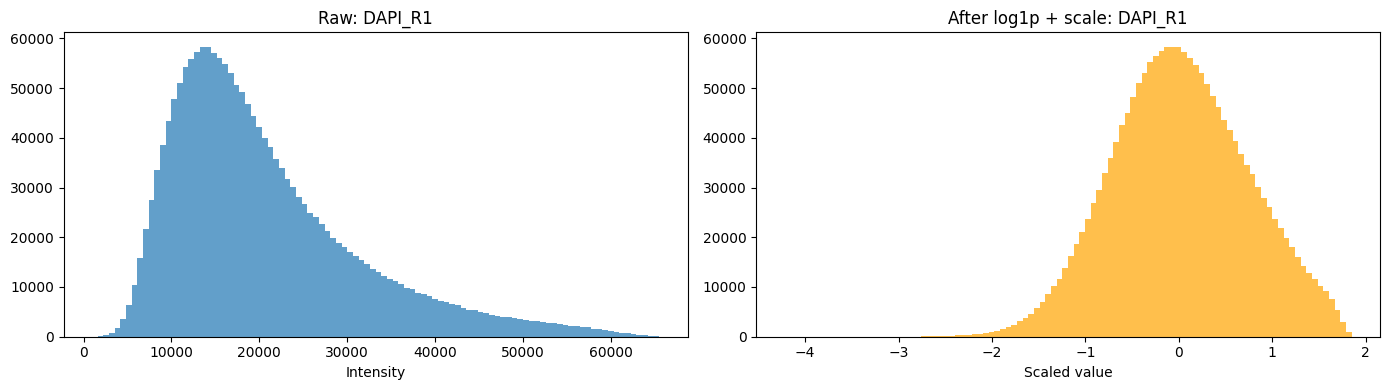

In [8]:
# log1p + RobustScaler
X_scaled, scaler = log1p_scale(X_raw)

print("After log1p + StandardScaler:")
print(f"  Shape: {X_scaled.shape}")
print(f"  Mean per marker (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"  Std per marker (should be ~1):  {X_scaled.std(axis=0).round(4)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(X_raw[:, 0].flatten(), bins=100, alpha=0.7, label="Raw")
axes[0].set_title(f"Raw: {adata.var_names[0]}")
axes[0].set_xlabel("Intensity")
axes[1].hist(X_scaled[:, 0].flatten(), bins=100, alpha=0.7, color="orange", label="Scaled")
axes[1].set_title(f"After log1p + scale: {adata.var_names[0]}")
axes[1].set_xlabel("Scaled value")
plt.tight_layout()
plt.show()

In [9]:
# Cycle assignment
marker_names = list(adata.var_names)
marker_cycles = assign_marker_cycles(marker_names, DEFAULT_CYCLE_CONFIG)

print("Marker -> Cycle mapping:")
for i, name in enumerate(marker_names):
    print(f"  {name:>12s}  ->  cycle {marker_cycles[i]}")

print(f"\nNumber of cycles: {marker_cycles.max() + 1}")
print(f"Markers per cycle: {dict(zip(*np.unique(marker_cycles, return_counts=True)))}")

Marker -> Cycle mapping:
       DAPI_R1  ->  cycle 0
         EPCAM  ->  cycle 1
          CD56  ->  cycle 1
          CD45  ->  cycle 1
          aSMA  ->  cycle 2
        ChromA  ->  cycle 2
          CK14  ->  cycle 2
          Ki67  ->  cycle 2
          GZMB  ->  cycle 3
          ECAD  ->  cycle 3
           PD1  ->  cycle 3
          CD31  ->  cycle 3
        CD45RA  ->  cycle 4
       HLADRB1  ->  cycle 4
           CD3  ->  cycle 4
           p53  ->  cycle 4
         FOXA1  ->  cycle 5
          CDX2  ->  cycle 5
          CD20  ->  cycle 5
        NOTCH1  ->  cycle 5

Number of cycles: 6
Markers per cycle: {np.int64(0): np.int64(1), np.int64(1): np.int64(3), np.int64(2): np.int64(4), np.int64(3): np.int64(4), np.int64(4): np.int64(4), np.int64(5): np.int64(4)}


## 3. Spatial k-NN Graph Construction

Inspect the spatial layout and the resulting neighborhood graph.

07:41:45 [INFO] Using 'scene_id' as scene column for spatial graph
Coordinates shape: (1760530, 2)
Unique scenes: 10
Coord ranges: x=[3.4, 50749.4], y=[1.5, 44019.7]


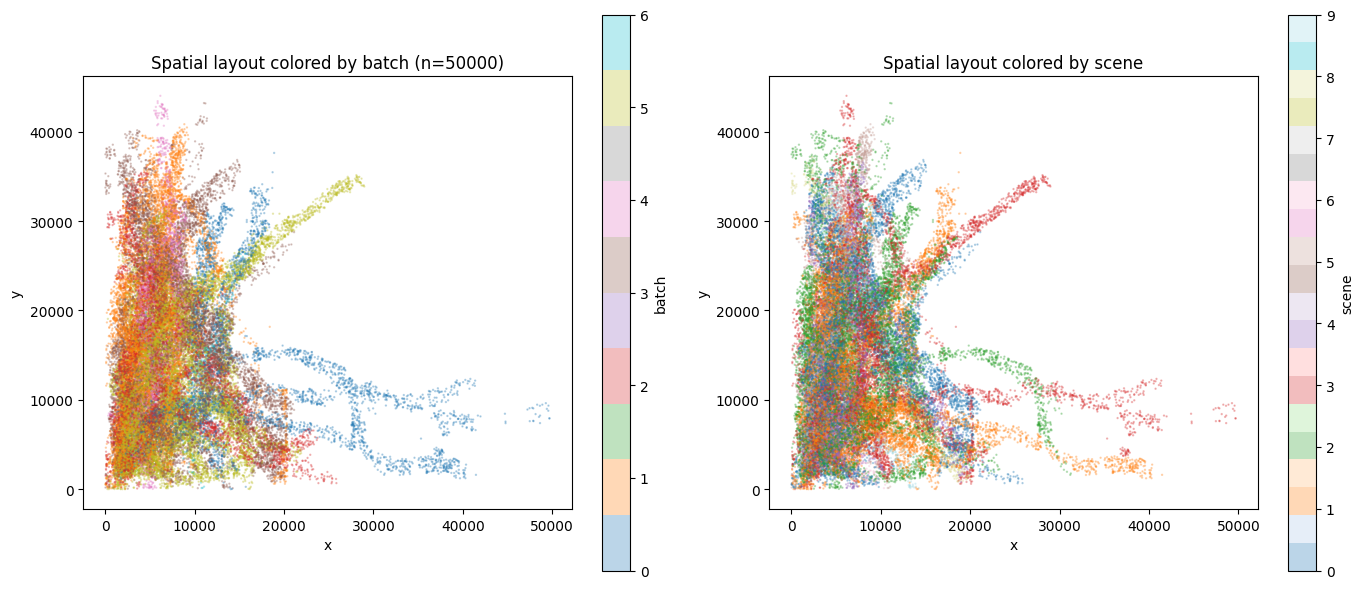

In [10]:
coords = get_spatial_coords(adata)
scene_ids = get_scene_ids(adata)

print(f"Coordinates shape: {coords.shape}")
print(f"Unique scenes: {np.unique(scene_ids).shape[0]}")
print(f"Coord ranges: x=[{coords[:,0].min():.1f}, {coords[:,0].max():.1f}], "
      f"y=[{coords[:,1].min():.1f}, {coords[:,1].max():.1f}]")

# Plot spatial layout colored by batch
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subsample for plotting if large
n_plot = min(50000, len(coords))
plot_idx = np.random.choice(len(coords), n_plot, replace=False)

scatter = axes[0].scatter(
    coords[plot_idx, 0], coords[plot_idx, 1],
    c=batch_codes[plot_idx], cmap="tab10", s=0.5, alpha=0.3
)
axes[0].set_title(f"Spatial layout colored by batch (n={n_plot})")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
plt.colorbar(scatter, ax=axes[0], label="batch")

scatter2 = axes[1].scatter(
    coords[plot_idx, 0], coords[plot_idx, 1],
    c=scene_ids[plot_idx], cmap="tab20", s=0.5, alpha=0.3
)
axes[1].set_title(f"Spatial layout colored by scene")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
plt.colorbar(scatter2, ax=axes[1], label="scene")
plt.tight_layout()
plt.show()

Building k-NN graph with k=15...
Edge index shape: (2, 26407950)
Total edges: 26,407,950
Avg edges/cell: 15.0


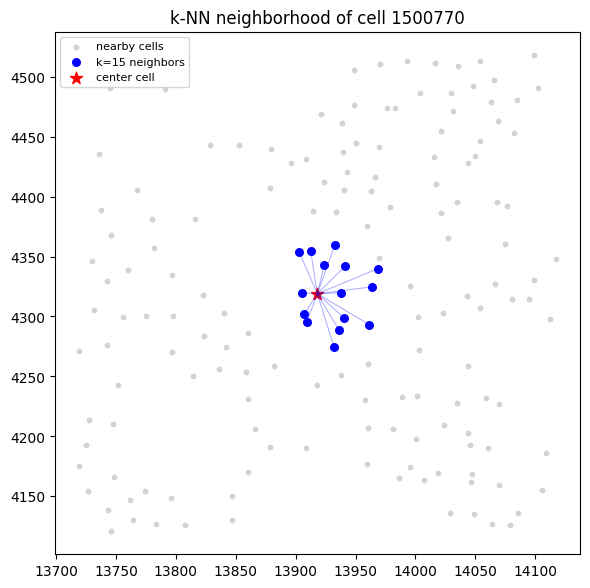

In [11]:
K = 15
print(f"Building k-NN graph with k={K}...")
edge_index_np = build_knn_graph(coords, scene_ids, k=K)
print(f"Edge index shape: {edge_index_np.shape}")
print(f"Total edges: {edge_index_np.shape[1]:,}")
print(f"Avg edges/cell: {edge_index_np.shape[1] / len(coords):.1f}")

# Visualize a small neighborhood
center_idx = np.random.randint(len(coords))
# Find all neighbors of center_idx
neighbor_mask = edge_index_np[0] == center_idx
neighbor_ids = edge_index_np[1, neighbor_mask]

fig, ax = plt.subplots(figsize=(6, 6))
# Plot nearby cells
radius = 200
nearby = np.where(
    (np.abs(coords[:, 0] - coords[center_idx, 0]) < radius) &
    (np.abs(coords[:, 1] - coords[center_idx, 1]) < radius)
)[0]
ax.scatter(coords[nearby, 0], coords[nearby, 1], c="lightgray", s=10, label="nearby cells")
ax.scatter(coords[neighbor_ids, 0], coords[neighbor_ids, 1], c="blue", s=30, label=f"k={len(neighbor_ids)} neighbors")
ax.scatter(coords[center_idx, 0], coords[center_idx, 1], c="red", s=80, marker="*", label="center cell")
for nid in neighbor_ids:
    ax.plot([coords[center_idx, 0], coords[nid, 0]],
            [coords[center_idx, 1], coords[nid, 1]], "b-", alpha=0.3, lw=0.8)
ax.set_title(f"k-NN neighborhood of cell {center_idx}")
ax.legend(fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Model Architecture Exploration

Instantiate each component and inspect shapes, parameter counts, and outputs.

In [ ]:
n_markers = adata.n_vars
n_batches = len(adata.obs["batch"].unique())
n_cycles = int(marker_cycles.max()) + 1

print(f"n_markers={n_markers}, n_batches={n_batches}, n_cycles={n_cycles}")

# --- CycleDegradationModel ---
cdm = CycleDegradationModel(n_batches, n_cycles, n_markers)
print(f"\nCycleDegradationModel params: {sum(p.numel() for p in cdm.parameters()):,}")

fake_batch = torch.randint(0, n_batches, (16,))
mc_t = torch.tensor(marker_cycles, dtype=torch.long)
gamma, beta = cdm(fake_batch, mc_t)
print(f"  gamma shape: {gamma.shape}, range: [{gamma.min():.3f}, {gamma.max():.3f}]")
print(f"  beta shape:  {beta.shape}, range: [{beta.min():.3f}, {beta.max():.3f}]")

# --- SpatialGNNEncoder ---
enc = SpatialGNNEncoder(n_markers, hidden=128, latent=64, heads=4)
print(f"\nSpatialGNNEncoder params: {sum(p.numel() for p in enc.parameters()):,}")

# Fake input: 100 cells, random edges
fake_x = torch.randn(100, n_markers)
fake_edges = torch.randint(0, 100, (2, 500))
z = enc(fake_x, fake_edges)
print(f"  Input: {fake_x.shape} -> Latent: {z.shape}")

# --- ResidualDecoder ---
dec = ResidualDecoder(latent=64, hidden=128, n_markers=n_markers)
print(f"\nResidualDecoder params: {sum(p.numel() for p in dec.parameters()):,}")
delta = dec(z)
print(f"  Latent: {z.shape} -> Delta: {delta.shape}")
print(f"  Delta mean: {delta.mean():.4f} (should be ~0 at init)")
print(f"  Delta std:  {delta.std():.4f} (should be small at init)")

# --- ProjectionHead ---
proj = ProjectionHead(latent=64, proj=32)
print(f"\nProjectionHead params: {sum(p.numel() for p in proj.parameters()):,}")
z_proj = proj(z)
print(f"  Latent: {z.shape} -> Projected: {z_proj.shape}")
print(f"  L2 norm of projections: {z_proj.norm(dim=-1).mean():.4f} (should be ~1.0)")

# --- BatchDiscriminator ---
disc = BatchDiscriminator(latent=64, n_batches=n_batches)
print(f"\nBatchDiscriminator params: {sum(p.numel() for p in disc.parameters()):,}")
logits = disc(z, grl_lambda=1.0)
print(f"  Latent: {z.shape} -> Batch logits: {logits.shape}")

In [ ]:
# --- Full SpaNCy model ---
model = SpaNCy(n_markers=n_markers, n_batches=n_batches, n_cycles=n_cycles)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Full SpaNCy model:")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print()

# Per-module breakdown
for name, module in model.named_children():
    n_p = sum(p.numel() for p in module.parameters())
    print(f"  {name:>20s}: {n_p:>8,} params")

print(f"\n{model}")

Full SpaNCy model:
  Total params:     103,523
  Trainable params: 103,523

           cycle_model:    6,056 params
               encoder:   78,016 params
               decoder:   10,900 params
             proj_head:    6,240 params
            batch_disc:    2,311 params

SpaNCy(
  (cycle_model): CycleDegradationModel(
    (batch_embed): Embedding(7, 32)
    (cycle_embed): Embedding(6, 16)
    (mlp): Sequential(
      (0): Linear(in_features=48, out_features=64, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=64, out_features=40, bias=True)
    )
  )
  (encoder): SpatialGNNEncoder(
    (input_proj): Linear(in_features=20, out_features=128, bias=True)
    (gat1): GATv2Conv(128, 32, heads=4)
    (gat2): GATv2Conv(128, 32, heads=4)
    (out_proj): Linear(in_features=128, out_features=64, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): Decoder(


## 5. Mini-Batch Sampling

Explore how `SpatialClusterSampler` groups spatially nearby cells across batches.

07:22:36 [INFO] Fitting 3521 spatial clusters...
Total spatial clusters: 3521
Steps per epoch: 293

Mini-batch 0: 710 cells
  batch 0: 116 cells
  batch 1: 23 cells
  batch 2: 161 cells
  batch 3: 102 cells
  batch 4: 26 cells
  batch 5: 274 cells
  batch 6: 8 cells

Mini-batch 1: 1426 cells
  batch 0: 46 cells
  batch 1: 217 cells
  batch 2: 175 cells
  batch 3: 411 cells
  batch 4: 500 cells
  batch 5: 58 cells
  batch 6: 19 cells

Mini-batch 2: 548 cells
  batch 0: 10 cells
  batch 1: 93 cells
  batch 2: 3 cells
  batch 3: 76 cells
  batch 4: 73 cells
  batch 5: 277 cells
  batch 6: 16 cells


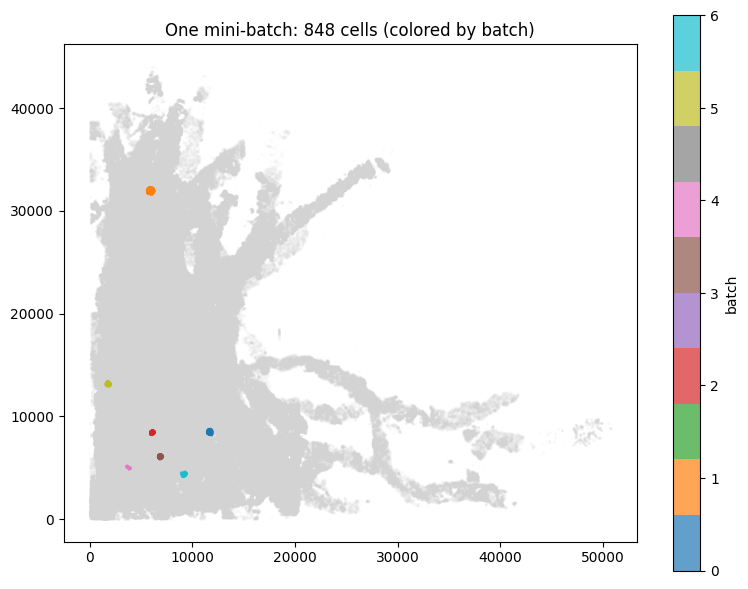

In [ ]:
batch_codes_np = adata.obs["batch"].astype("category").cat.codes.values.astype(np.int64)

sampler = SpatialClusterSampler(
    coords, batch_codes_np, cluster_size=500, cells_per_step=6000
)
print(f"Total spatial clusters: {sampler.n_clusters}")
print(f"Steps per epoch: {len(sampler)}")

# Draw a few mini-batches and inspect
for i in range(3):
    idx = sampler.sample()
    print(f"\nMini-batch {i}: {len(idx)} cells")
    unique_b, counts_b = np.unique(batch_codes_np[idx], return_counts=True)
    for b, c in zip(unique_b, counts_b):
        print(f"  batch {b}: {c} cells")

# Visualize one mini-batch spatially
idx = sampler.sample()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[:, 0], coords[:, 1], c="lightgray", s=0.1, alpha=0.1)
scatter = ax.scatter(
    coords[idx, 0], coords[idx, 1],
    c=batch_codes_np[idx], cmap="tab10", s=3, alpha=0.7
)
ax.set_title(f"One mini-batch: {len(idx)} cells (colored by batch)")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="batch")
plt.tight_layout()
plt.show()

## 6. Single Training Step — Forward & Backward Pass

Walk through one mini-batch: subgraph extraction, forward pass, loss computation, backward pass.

In [ ]:
device = torch.device("cuda")  # change to "cuda" if available

model = SpaNCy(n_markers=n_markers, n_batches=n_batches, n_cycles=n_cycles).to(device)
model.train()

marker_cycles_t = torch.tensor(marker_cycles, dtype=torch.long, device=device)
X_all = torch.tensor(X_scaled, dtype=torch.float32)
batch_all = torch.tensor(batch_codes_np, dtype=torch.long)

# Sample a mini-batch
idx = sampler.sample()
print(f"Mini-batch: {len(idx)} cells")

# Extract subgraph
edge_local, n_local = build_subgraph(edge_index_np, idx)
edge_local = edge_local.to(device)
print(f"Subgraph edges: {edge_local.shape[1]}")

# Prepare tensors
X_batch = X_all[idx].to(device)
batch_ids = batch_all[idx].to(device)

# Forward pass
out = model(X_batch, edge_local, batch_ids, marker_cycles_t, grl_lambda=0.5)

print(f"\nForward pass outputs:")
for k, v in out.items():
    print(f"  {k:>15s}: shape={list(v.shape)}, "
          f"min={v.min().item():.4f}, max={v.max().item():.4f}, "
          f"mean={v.mean().item():.4f}")

Mini-batch: 284 cells
Subgraph edges: 1743

Forward pass outputs:
      X_corrected: shape=[284, 20], min=-5.5397, max=12.3188, mean=-0.1437
                z: shape=[284, 64], min=-2.0205, max=2.0018, mean=0.0475
          X_recon: shape=[284, 20], min=-0.5308, max=0.3615, mean=-0.0141
           z_proj: shape=[284, 32], min=-0.5103, max=0.5209, mean=-0.0092
     batch_logits: shape=[284, 7], min=-0.3670, max=0.5283, mean=0.0373


In [ ]:
# Compute individual losses
huber = nn.HuberLoss(delta=1.0)
ce = nn.CrossEntropyLoss()

loss_recon = huber(out["X_recon"], out["X_corrected"])
loss_contrast = nt_xent_loss(out["z_proj"], edge_local, tau=0.1)
loss_adv = ce(out["batch_logits"], batch_ids)
loss_align = location_scale_loss(out["X_recon"], batch_ids)
loss_total = loss_recon + 0.5 * loss_contrast + 0.3 * loss_adv + 0.3 * loss_align

print("Losses:")
print(f"  L_recon:    {loss_recon.item():.4f}")
print(f"  L_contrast: {loss_contrast.item():.4f}")
print(f"  L_adv:      {loss_adv.item():.4f}")
print(f"  L_align:    {loss_align.item():.4f}")
print(f"  L_total:    {loss_total.item():.4f}")

# Inspect the residual delta
print(f"\nResidual delta stats:")
print(f"  mean: {out['delta'].mean().item():.6f}")
print(f"  std:  {out['delta'].std().item():.6f}")
print(f"  max abs: {out['delta'].abs().max().item():.6f}")

# Backward pass
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer.zero_grad()
loss_total.backward()

# Inspect gradient norms per module
print("\nGradient norms per module:")
for name, module in model.named_children():
    grad_norm = 0.0
    n_params = 0
    for p in module.parameters():
        if p.grad is not None:
            grad_norm += p.grad.norm().item() ** 2
            n_params += 1
    grad_norm = grad_norm ** 0.5
    print(f"  {name:>20s}: grad_norm={grad_norm:.6f} ({n_params} tensors)")

torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
optimizer.step()
print("\nStep complete.")

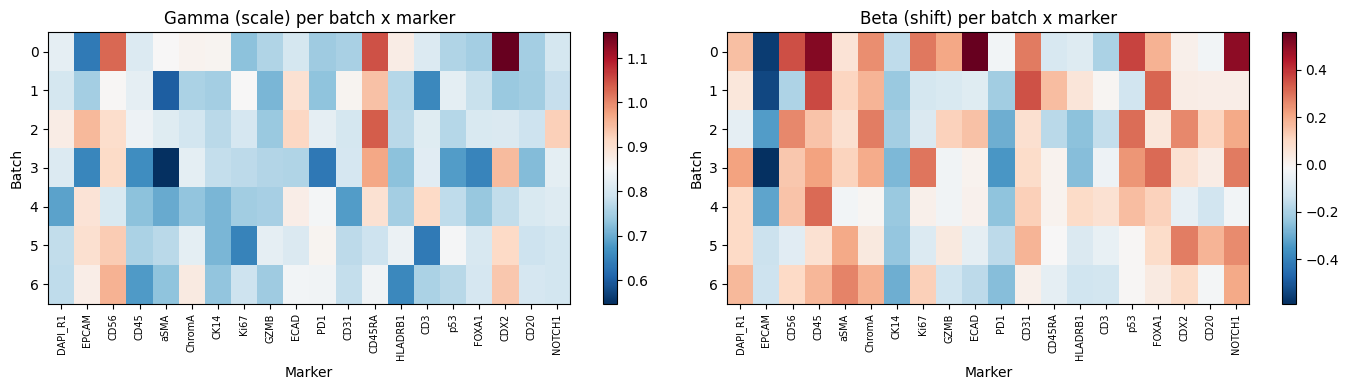

In [ ]:
# Inspect the cycle degradation model's learned correction
with torch.no_grad():
    gamma, beta = model.cycle_model(
        torch.arange(n_batches, device=device), marker_cycles_t
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im0 = axes[0].imshow(gamma.cpu().numpy(), aspect="auto", cmap="RdBu_r")
axes[0].set_title("Gamma (scale) per batch x marker")
axes[0].set_ylabel("Batch"); axes[0].set_xlabel("Marker")
axes[0].set_xticks(range(n_markers))
axes[0].set_xticklabels(marker_names, rotation=90, fontsize=7)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(beta.cpu().numpy(), aspect="auto", cmap="RdBu_r")
axes[1].set_title("Beta (shift) per batch x marker")
axes[1].set_ylabel("Batch"); axes[1].set_xlabel("Marker")
axes[1].set_xticks(range(n_markers))
axes[1].set_xticklabels(marker_names, rotation=90, fontsize=7)
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

## 7. Full Training Loop

Run the full `train()` function and monitor loss curves.

In [ ]:
# Customize training parameters here
DEVICE = "cuda"      # "cuda" for GPU
N_EPOCHS = 5    # reduce for quick testing (e.g. 10)
LR = 1e-3
K = 15

trained_model, fitted_scaler, trained_marker_cycles, history = train(
    adata,
    cycle_config=DEFAULT_CYCLE_CONFIG,
    n_epochs=N_EPOCHS,
    lr=LR,
    k_neighbors=K,
    device_str=DEVICE,
)

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs = range(1, len(history["loss"]) + 1)

axes[0].plot(epochs, history["loss"], "k-", label="Total", linewidth=2)
axes[0].plot(epochs, history["recon"], "b-", alpha=0.7, label="Recon")
axes[0].plot(epochs, history["contrast"], "r-", alpha=0.7, label="Contrast")
axes[0].plot(epochs, history["adv"], "g-", alpha=0.7, label="Adversarial")
axes[0].plot(epochs, history["align"], "m-", alpha=0.7, label="Align")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss Curves")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["lr"], "b-")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Learning Rate")
axes[1].set_title("Learning Rate Schedule")
axes[1].set_yscale("log"); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history["grl_lambda"], "r-")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("GRL Lambda")
axes[2].set_title("Gradient Reversal Ramp")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal losses — total: {history['loss'][-1]:.4f}, "
      f"recon: {history['recon'][-1]:.4f}, "
      f"contrast: {history['contrast'][-1]:.4f}, "
      f"adv: {history['adv'][-1]:.4f}, "
      f"align: {history['align'][-1]:.4f}")

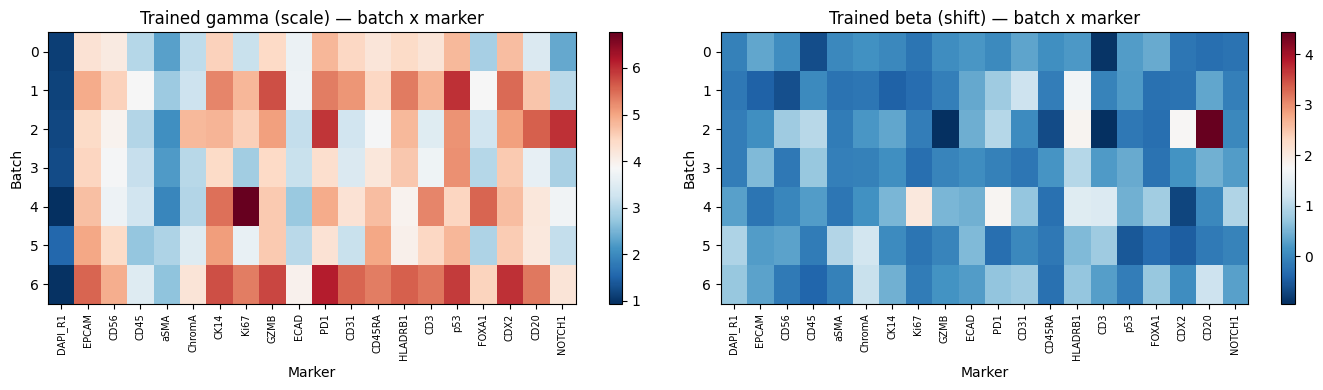

Top 5 largest gamma deviations from 1.0:
  batch 4, Ki67: gamma=6.7651
  batch 6, PD1: gamma=6.1486
  batch 1, p53: gamma=5.9887
  batch 6, CDX2: gamma=5.9869
  batch 2, NOTCH1: gamma=5.9834


In [ ]:
# Inspect trained cycle degradation parameters
with torch.no_grad():
    gamma_t, beta_t = trained_model.cycle_model(
        torch.arange(n_batches, device=torch.device(DEVICE)),
        torch.tensor(trained_marker_cycles, dtype=torch.long, device=torch.device(DEVICE)),
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im0 = axes[0].imshow(gamma_t.cpu().numpy(), aspect="auto", cmap="RdBu_r")
axes[0].set_title("Trained gamma (scale) — batch x marker")
axes[0].set_ylabel("Batch"); axes[0].set_xlabel("Marker")
axes[0].set_xticks(range(n_markers))
axes[0].set_xticklabels(marker_names, rotation=90, fontsize=7)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(beta_t.cpu().numpy(), aspect="auto", cmap="RdBu_r")
axes[1].set_title("Trained beta (shift) — batch x marker")
axes[1].set_ylabel("Batch"); axes[1].set_xlabel("Marker")
axes[1].set_xticks(range(n_markers))
axes[1].set_xticklabels(marker_names, rotation=90, fontsize=7)
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

# Which batches/markers have the largest corrections?
print("Top 5 largest gamma deviations from 1.0:")
gamma_dev = (gamma_t.cpu().numpy() - 1.0)
for _ in range(5):
    idx_flat = np.argmax(np.abs(gamma_dev))
    b_i, m_i = np.unravel_index(idx_flat, gamma_dev.shape)
    print(f"  batch {b_i}, {marker_names[m_i]}: gamma={gamma_t[b_i, m_i]:.4f}")
    gamma_dev[b_i, m_i] = 0

## 8. Inference & Output Inspection

Run inference, store normalized values, and inspect the results.

In [ ]:
from spancy import normalize_adata

# mode="affine" (default): per-batch gamma/beta correction, preserves shape.
# mode="residual": full GNN pipeline, stronger alignment but distorts shape.
#
# align_samples=True (default): post-hoc per-sample median shift.
#   For each marker, slides each sample's distribution so its median matches
#   the global median. Pure translation — zero shape distortion.

adata = normalize_adata(
    adata,
    trained_model,
    fitted_scaler,
    trained_marker_cycles,
    k_neighbors=K,
    device_str=DEVICE,
    mode="affine",
    align_samples=True,  # set False to see affine-only
)

print(f"Layers: {list(adata.layers.keys())}")
X_norm = adata.layers["normalized"]
print(f"\nNormalized expression stats:")
print(f"  Shape:  {X_norm.shape}")
print(f"  Min:    {X_norm.min():.4f}")
print(f"  Max:    {X_norm.max():.4f}")
print(f"  Mean:   {X_norm.mean():.4f}")
print(f"  Median: {np.median(X_norm):.4f}")
print(f"  Any negative? {(X_norm < 0).any()}")

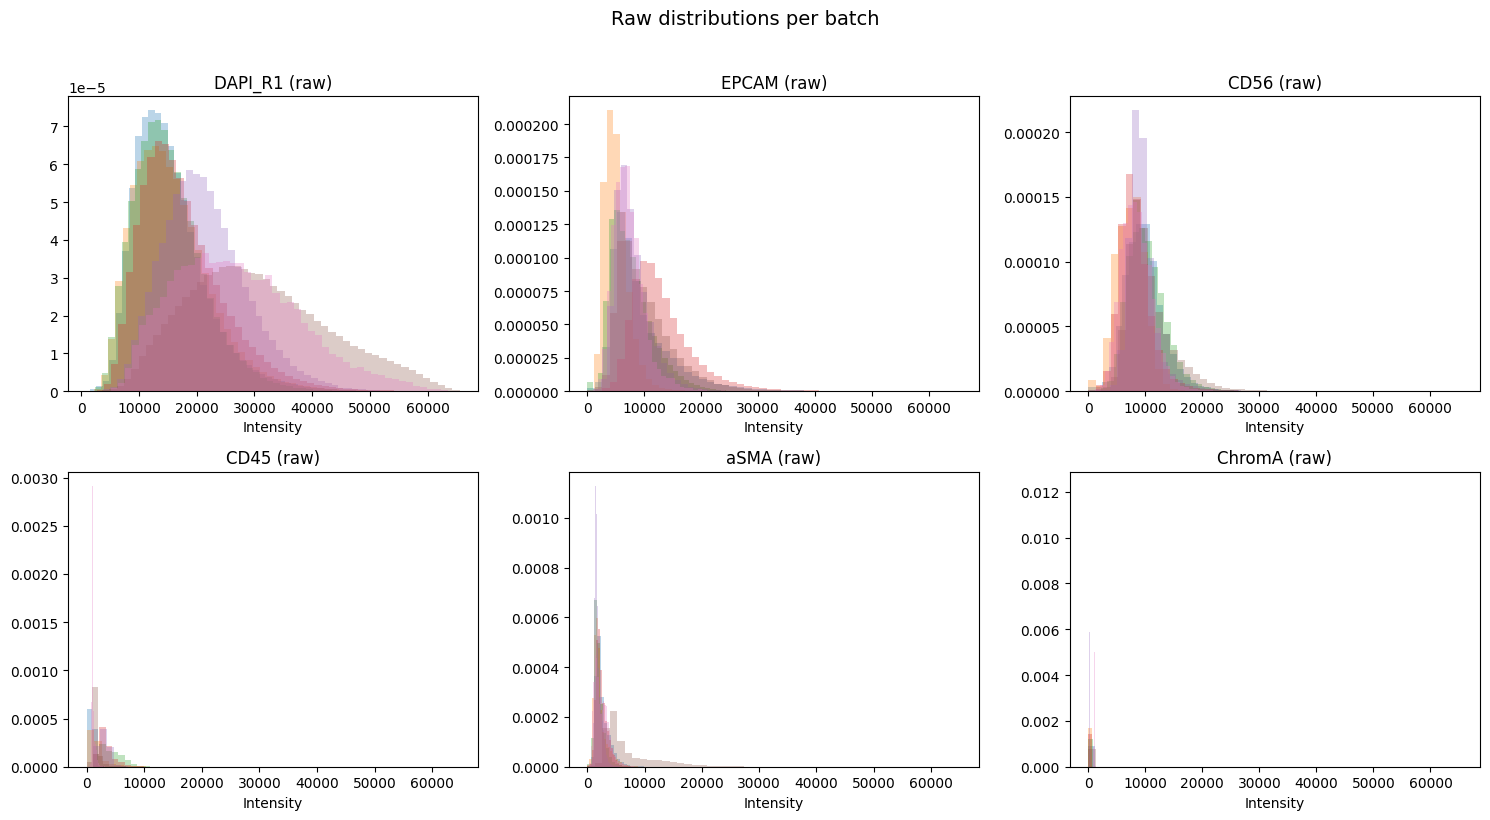

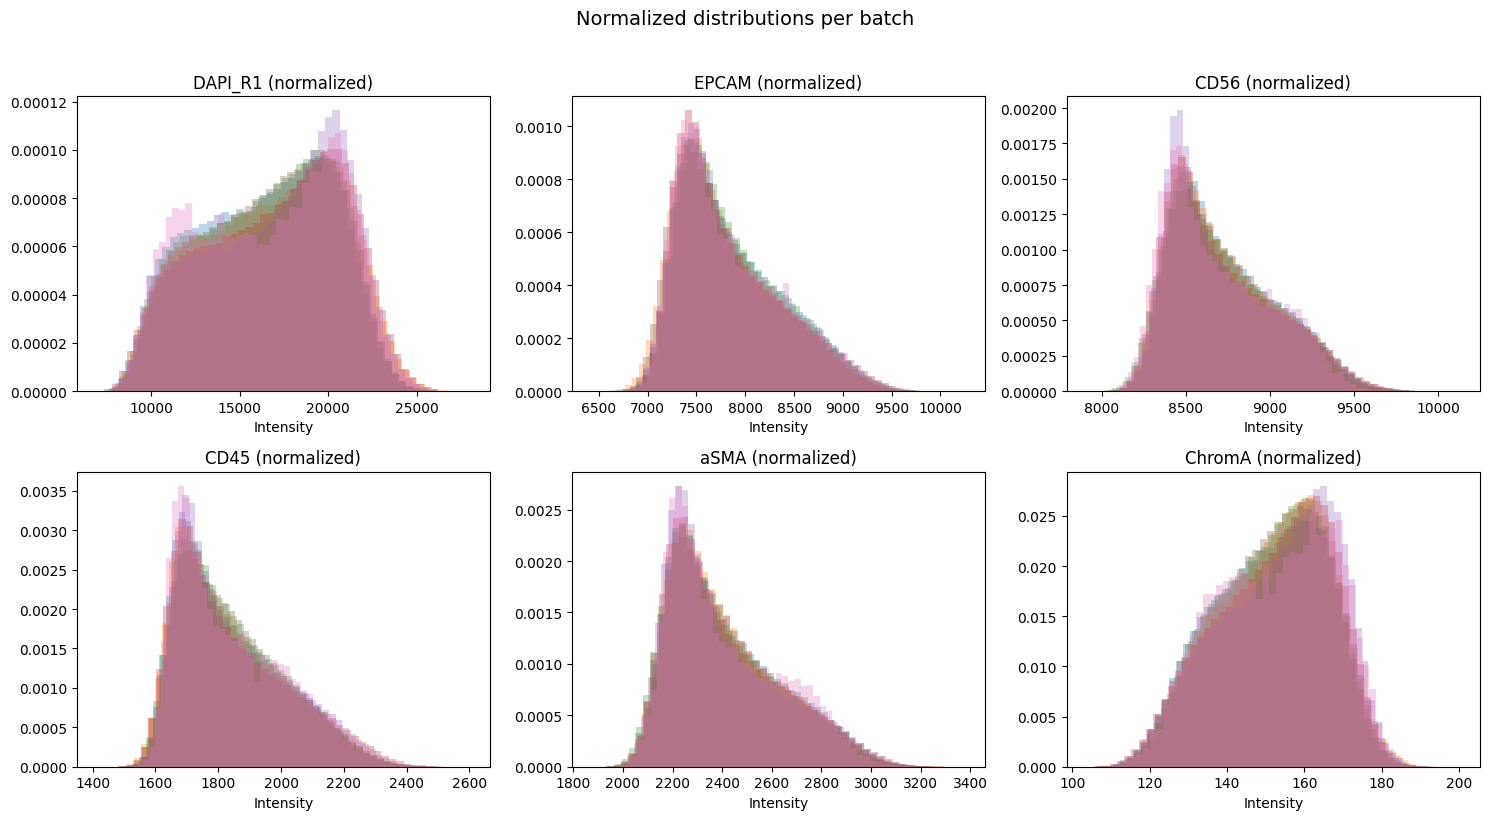

In [ ]:
# Compare raw vs normalized distributions for selected markers
markers_to_plot = marker_names[:6]  # first 6 markers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (ax, mname) in enumerate(zip(axes.flat, markers_to_plot)):
    m_idx = marker_names.index(mname)
    for b in range(n_batches):
        mask = batch_codes_np == b
        ax.hist(X_raw[mask, m_idx], bins=50, alpha=0.3, density=True, label=f"raw b{b}")
    ax.set_title(f"{mname} (raw)")
    ax.set_xlabel("Intensity")

plt.suptitle("Raw distributions per batch", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (ax, mname) in enumerate(zip(axes.flat, markers_to_plot)):
    m_idx = marker_names.index(mname)
    for b in range(n_batches):
        mask = batch_codes_np == b
        ax.hist(X_norm[mask, m_idx], bins=50, alpha=0.3, density=True, label=f"norm b{b}")
    ax.set_title(f"{mname} (normalized)")
    ax.set_xlabel("Intensity")

plt.suptitle("Normalized distributions per batch", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

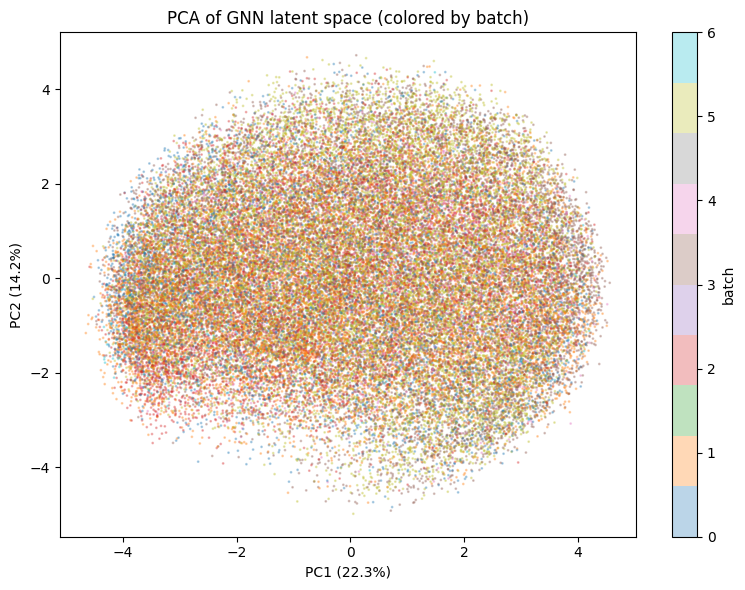

Latent dim: 64
PCA variance explained: 36.5%


In [ ]:
# Latent space exploration — encode all cells and inspect
from sklearn.decomposition import PCA

trained_model.eval()
device_t = torch.device(DEVICE)

# Encode a subsample for visualization
n_sub = min(50000, adata.n_obs)
sub_idx = np.random.choice(adata.n_obs, n_sub, replace=False)

X_sub = torch.tensor(X_scaled[sub_idx], dtype=torch.float32, device=device_t)
batch_sub = torch.tensor(batch_codes_np[sub_idx], dtype=torch.long, device=device_t)
mc_t = torch.tensor(trained_marker_cycles, dtype=torch.long, device=device_t)

edge_sub, _ = build_subgraph(edge_index_np, sub_idx)
edge_sub = edge_sub.to(device_t)

with torch.no_grad():
    X_corr = trained_model.cycle_model.correct(X_sub, batch_sub, mc_t)
    z_sub = trained_model.encoder(X_corr, edge_sub)

z_np = z_sub.cpu().numpy()

# PCA of latent space
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_np)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(z_pca[:, 0], z_pca[:, 1], c=batch_codes_np[sub_idx],
                     cmap="tab10", s=1, alpha=0.3)
ax.set_title("PCA of GNN latent space (colored by batch)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, ax=ax, label="batch")
plt.tight_layout()
plt.show()

print(f"Latent dim: {z_np.shape[1]}")
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [ ]:
# Save the normalized output
OUTPUT_PATH = "PRAD_normalized.h5ad"
adata.write_h5ad(OUTPUT_PATH)
print(f"Saved to {OUTPUT_PATH}")
print(f"  {adata.n_obs} cells x {adata.n_vars} markers")
print(f"  layers: {list(adata.layers.keys())}")

Saved to PRAD_normalized.h5ad
  1760530 cells x 20 markers
  layers: ['normalized']


In [ ]:
adata_denoised = ad.read_h5ad("PRAD_normalized.h5ad")

In [ ]:
"""
Plotting histograms for each marker one by one in folder "histograms_logintensity_by_sample"
Also creates a PDF where each page contains 9 histograms (3×3) in horizontal landscape layout.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.backends.backend_pdf import PdfPages

# === SETTINGS ===
layer_name = "normalized"
group_col = "sample_id"
marker_col = "marker_name"
max_markers = None
save_dir = "histograms_logintensity_by_sample"

os.makedirs(save_dir, exist_ok=True)

# === PDF SETUP ===
pdf_path = os.path.join(save_dir, "all_markers_histograms_9perpage_horizontal.pdf")
pdf = PdfPages(pdf_path)
fig_batch = []   # store up to 9 figures before writing a PDF page

# === MARKERS ===
markers = adata_denoised.var[marker_col].values
if max_markers:
    markers = markers[:max_markers]

# === COLOR MAP ===
unique_groups = adata_denoised.obs[group_col].astype(str).unique()
cmap = cm.get_cmap("tab20")
group_colors = {g: cmap(i % 20) for i, g in enumerate(unique_groups)}

# === LOOP THROUGH MARKERS ===
for i, marker in enumerate(markers):
    # Extract data
    X_marker = adata_denoised.layers[layer_name][:, i]
    if hasattr(X_marker, "toarray"):
        X_marker = X_marker.toarray().flatten()
    else:
        X_marker = np.array(X_marker).flatten()

    # Clean + log-transform
    X_marker = np.nan_to_num(X_marker, nan=0.0)
    X_marker = np.clip(X_marker, a_min=0, a_max=None)
    X_marker_log = np.log1p(X_marker)

    # Sample info
    sample_ids = adata_denoised.obs[group_col].astype(str).values
    df = pd.DataFrame({
        "log_intensity": X_marker_log,
        group_col: sample_ids
    })

    sample_counts = df[group_col].value_counts().to_dict()

    # === Plot styling ===
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(marker, fontsize=12, fontweight="bold")
    ax.set_xlabel("Log(Cell Mean Intensity)", fontsize=10, fontweight="bold")
    ax.set_ylabel("Frequency", fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params(width=2)

    # Plot per sample
    for g in unique_groups:
        subset = df[df[group_col] == g]["log_intensity"]
        counts, edges = np.histogram(subset, bins=80)
        ax.plot(
            edges[:-1],
            counts,
            color=group_colors[g],
            linewidth=2,
            alpha=0.8,
            label=f"{g} (n={sample_counts.get(g, 0)})"
        )

    # Legend (kept inside figure, but not overlapping)
    if len(unique_groups) > 1:
        ax.legend(
            title="Sample",
            fontsize=8,
            loc="upper right",
            frameon=False
        )
    else:
        ax.legend().remove()

    plt.tight_layout()

    # === Save PNG ===
    plt.savefig(f"{save_dir}/{i:02d}_{marker}_histogram.png", dpi=150)

    # === Add to PDF batch ===
    fig_batch.append(fig)

    # === When 9 figures collected OR last marker → write PDF page ===
    if len(fig_batch) == 9 or i == len(markers) - 1:
        page_fig, axes = plt.subplots(3, 3, figsize=(18, 12))  # horizontal landscape
        axes = axes.flatten()

        for ax_idx, single_fig in enumerate(fig_batch):
            src_ax = single_fig.axes[0]
            dst_ax = axes[ax_idx]

            # Copy lines
            for line in src_ax.lines:
                dst_ax.plot(
                    line.get_xdata(),
                    line.get_ydata(),
                    color=line.get_color(),
                    linewidth=line.get_linewidth(),
                    alpha=line.get_alpha(),
                    label=line.get_label()
                )

            # Titles and labels
            dst_ax.set_title(src_ax.get_title(), fontsize=12, fontweight="bold")
            dst_ax.set_xlabel(src_ax.get_xlabel())
            dst_ax.set_ylabel(src_ax.get_ylabel())

            # Legend placed next to plot (not overlapping)
            if src_ax.get_legend() is not None:
                dst_ax.legend(
                    title="Sample",
                    fontsize=6,
                    loc="upper right",
                    bbox_to_anchor=(1.25, 1.0),  # move legend outside plot
                    frameon=False
                )

            dst_ax.spines["top"].set_visible(False)
            dst_ax.spines["right"].set_visible(False)

        # Hide unused axes
        for j in range(len(fig_batch), 9):
            axes[j].axis("off")

        plt.tight_layout()
        pdf.savefig(page_fig)
        plt.close(page_fig)

        fig_batch = []  # reset batch

    plt.close(fig)

    if i % 5 == 0:
        print(f"Plotted {i+1}/{len(markers)} markers...")

# === CLOSE PDF ===
pdf.close()

print(f"\nPDF saved to: {pdf_path}")
print(f"Histograms generated for {len(markers)} markers in '{save_dir}/'")

/tmp/ipykernel_17289/219499869.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20")


Plotted 1/20 markers...
Plotted 6/20 markers...
Plotted 11/20 markers...
Plotted 16/20 markers...

PDF saved to: histograms_logintensity_by_sample/all_markers_histograms_9perpage_horizontal.pdf
Histograms generated for 20 markers in 'histograms_logintensity_by_sample/'
